In [39]:
from typing_extensions import TypedDict, Literal, Annotated
from typing import List
from langgraph.types import Send
from langgraph.graph import StateGraph, START, END
from langchain.chat_models import init_chat_model
from pydantic import BaseModel
from operator import add

llm = init_chat_model("openai:gpt-4o")

dumb_llm = init_chat_model("openai:gpt-3.5-turbo")
average_llm = init_chat_model("openai:gpt-4")
smart_llm = init_chat_model("openai:gpt-5")

In [40]:
class State(TypedDict):

    document: str
    final_summary: str
    summaries: Annotated[list[dict], add]


In [ ]:
def summarize_p(state):
    paragraph = state["paragraph"]
    index = state["index"]
    response = llm.invoke(
        f"write a 3-sentence summary of this paragraph: {paragraph}",
    )
    return{
        "summaries": [
            {
                'summary':response.content, 
                'index':index
            }
        ],
    }

def dispatch_summaries(state: State):
    chunks = state["document"].split("\n\n")
    return [
        Send("summarize_p", {"paragraph": chunk, "index": i}) 
        for i, chunk in enumerate(chunks)
    ]
    
def final_summary(state: State):
    response = llm.invoke(
        f"Using the following summaries, give me a final one {state['summaries'].sort(key=lambda x: x['index'])}"
    )
    return {
        "final_summary": response.content
        }


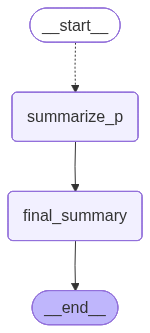

In [45]:
graph_builder = StateGraph(State)

graph_builder.add_node("summarize_p", summarize_p)
graph_builder.add_node("final_summary", final_summary)

graph_builder.add_conditional_edges(
    START, 
    dispatch_summaries, 
    ["summarize_p"])

graph_builder.add_edge("summarize_p", "final_summary")
graph_builder.add_edge("final_summary", END)


graph = graph_builder.compile()

graph

In [46]:
with open("fed_transcript.md", "r", encoding="utf-8") as file:
    document = file.read()


for chunk in graph.stream(
    {"document": document},
    stream_mode="updates",
    ):
    print(chunk, "\n")
    

{'summarize_p': {'summaries': [{'summary': 'In the labor market, the unemployment rate slightly increased to 4.3 percent in August. However, this change is minimal over the past year. Overall, the rate remains at a relatively low level.', 'index': 5}]}} 

{'summarize_p': {'summaries': [{'summary': "Recent data shows that economic growth has slowed. Gross Domestic Product (GDP) increased by about 1.5% in the first half of the year. This represents a decline from the previous year's growth rate of 2.5%.", 'index': 1}]}} 

{'summarize_p': {'summaries': [{'summary': 'The moderation and growth are primarily attributed to a decrease in consumer spending. This reduction in expenditures has had a significant impact on economic trends. As consumer spending slows, it influences the overall pace of economic growth.', 'index': 2}]}} 

{'summarize_p': {'summaries': [{'summary': 'Business investment in equipment and intangibles has increased compared to the previous year. This change indicates a shi

AttributeError: 'AIMessage' object has no attribute 'sort'